# Hotel Booking: cómo afectan las cancelaciones a los hoteles

Las cancelaciones de reservas representan un desafío para la industria hotelera, ya que generan pérdidas en los ingresos, provocan una mala planificación en la ocupación y derivan en sobrecostes operativos. Estas cancelaciones pueden estar relacionadas con factores como políticas de cancelación flexibles, el uso de múltiples plataformas de reserva o la ausencia de penalizaciones por cancelar en el último minuto, entre otras.

El dataset analizado recoge reservas realizadas entre el año 2015 y 2017, de las que aproximadamente un 37% son reservas canceladas, lo que indica la importancia de este fenómeno durante este periodo. El objetivo de este estudio es desarrollar un modelo de clasificación binaria capaz de predecir con antelación la probabildiad de cancelación de una reserva, permitiendo a los hoteles elaborar estrategias de actuación que reduzcan el impacto económico y operativo de las cancelaciones, apoyándose en datos históricos.

Este problema se puede abordar con Machine Learning porque disponemos de un historial de reservas con múltiples variables predictoras (tipo de hotel, tiempo de anticipación, número de adultos, plataforma de reserva, etc.) y un target binario (cancelada/no cancelada). Existen patrones en los datos que los algoritmos de clasificación supervisada pueden aprender para predecir futuras cancelaciones.

Se propone un enfoque de clasificación supervisada, porque el objetivo es predecir una variable binaria conocida a partir de características históricas. Este enfoque permite estimar probabilidades de cancelación para nuevas reservas y, por tanto, guiar decisiones operativas. Algoritmos como Random Forest, XGBoost o regresión logística son adecuados dado que manejan variables categóricas y numéricas, toleran relaciones no lineales y permiten interpretar la importancia de las variables.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split

np.random.seed(42)


In [12]:
# Cargamos el dataset, le echamos un vistazo, vemos su información y descripción:
df = pd.read_csv("../data_sample/hotel_booking.csv", sep= ",")
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Jasmine Fletcher,JFletcher43@xfinity.com,190-271-6743,************9263
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,Transient,107.0,0,0,Check-Out,2015-07-03,Dylan Rangel,Rangel.Dylan@comcast.net,420-332-5209,************6994
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,Transient,103.0,0,1,Check-Out,2015-07-03,William Velez,Velez_William@mail.com,286-669-4333,************8729
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,Transient,82.0,0,1,Canceled,2015-05-06,Steven Murphy,Steven.Murphy54@aol.com,341-726-5787,************3639
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,Transient,105.5,0,0,Canceled,2015-04-22,Michael Moore,MichaelMoore81@outlook.com,316-648-6176,************9190


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# Buscamos los nulos:
df.isna().sum()
# tenemos 4 variables con nulos: children, country, agent y company. 

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [14]:
# Vemos el balance en las cancelaciones, interpretando que 0 es "no", y 1 es "sí",
# No hay un desbalance grande, y nos sirve para confirmar que las cancelaciones son
# un problema relevante.
df["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

## Análisis inicial del dataset 
El dataset tiene un total de 119.390 filas y 36 columnas. De estas columnas, 16 son tipo string, 16 de tipo int y 4 de tipo float. 

### Clasificación inicial de variables: 

- **Variables numéricas continuas:** lead_time, adr. 

- **Variables numéricas discretas:** adults, children, babies, required_car_parking_spaces, total_of_special_requests, days_in_waiting_list, previous_cancellations, previous_bookings_not_canceled, booking_changes, stays_in_week_nights, stays_in_weekend_nights, arrival_date_year, arrival_date_day_of_month, arrival_date_week_number.
- **Variables categóricas:** hotel, customer_type, market_segment, deposit_type, **reservation_status**, name, email, phone-number, credit_card, meal, country, distribution_channel, reserved_room_type, assigned_room_type, agent, company, arrival_date_month.

- **Variables binarias:** is_repeated_guest.

- **Variables temporales:** reservation_status_date.

- **Variable objetivo:** is_canceled.

La tipificación inicial se realizó inspeccionando las variables y sus valores únicos, asegurando que la separación entre continuas, discretas, categóricas, binarias y temporales sea coherente con la naturaleza de los datos.



### Train/Test split:

Nuestra variable target es: is_cancelled

In [16]:
target = "is_canceled"

In [ ]:
# hacemos copia del df y hacemos nuestro split:
df_hotel = df.copy()

X = df_hotel.drop(columns="is_canceled")
y = df_hotel["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Análisis del target - is_cancelled:

En nuestro set de train, un 63% de las reservas no son canceladas, frente al 36% que sí cancelan:

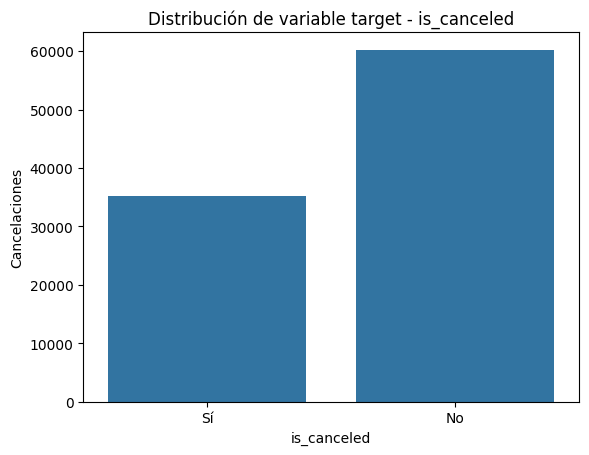

In [20]:
# vemos la distribución del target, donde 0 es "No" y 1 es "Sí" y usamos map para cambiar
# estos valores y visualizar:
y_train_etiquetas = y_train.map({0: "No", 1: "Sí"})

sns.countplot(x=y_train_etiquetas)
plt.title("Distribución de variable target - is_canceled")
plt.ylabel("Cancelaciones")
plt.show();

In [23]:
# Vemos el porcentaje de cancelaciones en nuestro train, muy similar al df original:
print(y_train.value_counts(normalize=True) * 100)


is_canceled
0    63.090502
1    36.909498
Name: proportion, dtype: float64


### Análisis temporal para detectar estacionalidad:
Nuestro target puede verse afectado por las variables temporales que tenemos. Veamos la relación que tienen: 
- Inicialmente, hay casi 3 veces más de cancelaciones en el 2016 que en el 2015.
- Sin embargo, al revisar la media de las cancelaciones por meses y años, vemos que no tenemos información de todos los meses de los años:
    - del 2015, tenemos información de 6 meses, de julio a diciembre.
    - del 2016, tenemos información de todos los meses del año.
    - del 2017 tenemos información de 8 meses, de enero a agosto solamente. 
- A partir de esto, vemos que en el 2015 el mayor mes de cancelación fue en julio; en el 2016, fue en octubre; en 2017 fue mayor y similar en abril, mayo y junio.

In [33]:
df_train.arrival_date_year.value_counts()

arrival_date_year
2016    45355
2017    32550
2015    17607
Name: count, dtype: int64

In [ ]:
# Agrupamos por años y meses y calculamos la media de las cancelaciones, para establecer temporalidad:
df_train = X_train.copy()
df_train["is_canceled"] = y_train

cancel_by_month = (df_train.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"].mean() * 100).sort_index()
print(cancel_by_month)

arrival_date_year  arrival_date_month
2015               August                41.241469
                   December              32.715517
                   July                  45.235935
                   November              20.378151
                   October               34.606685
                   September             40.650012
2016               April                 37.764004
                   August                35.448954
                   December              36.286645
                   February              34.440503
                   January               24.916201
                   July                  32.984004
                   June                  39.084006
                   March                 30.482115
                   May                   35.187698
                   November              36.968160
                   October               40.540541
                   September             37.294036
2017               April                 43.

#### Veamoslo gráficamente con un heatmap:

In [35]:
# ordenamos los meses:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
# pd.Categorical para convertir la col arrival_date_month en un tipo categórico ordenado, en vez de str ya que los ordena alfabéticamente.
df_train["arrival_date_month"] = pd.Categorical(
    df_train["arrival_date_month"],
    categories=month_order,
    ordered=True
)

In [36]:
# Creamos la tabla pivote:
pivot = (df_train.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"].mean().unstack() * 100)
# unstack convierte la segunda col arrival_date_month en columnas y deja los años como filas, y 
# resulta una matriz tipo tabla con años vs meses

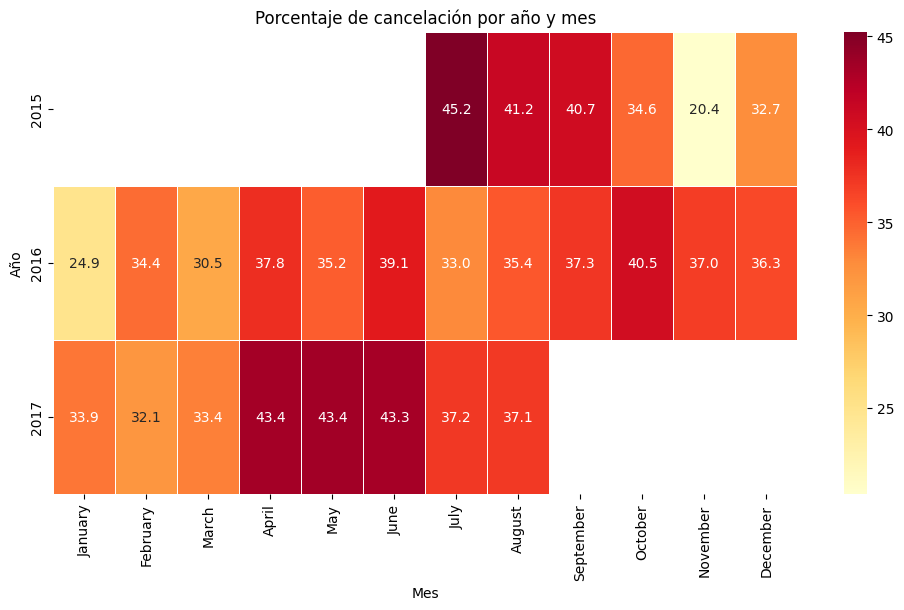

In [37]:
# Dibujamos el heatmap:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot, # usa la tabla pivote
    annot=True, # muestra los valores numéricos dentro de cada celda
    fmt=".1f", # con un decimal
    cmap="YlOrRd", # escala de colores amarillo a rojo
    linewidths=0.5 # separación entre celdas
)

plt.title("Porcentaje de cancelación por año y mes")
plt.ylabel("Año")
plt.xlabel("Mes")
plt.show();

### Resultados visuales:
- En el 2015, hubo más cancelaciones en julio, agosto y septiembre, temporada de verano.
- En el 2016, la tasa de cancelaciones se concentró en abril, junio y octubre, siendo octubre el mes con más cancelaciones, no hay una temporada clara.
- En el 2017, se concentraron las cancelaciones entre abril, mayo y junio, estando bastante igualadas en porcentaje, en la temporada de primavera.

### Análisis de variables numéricas:


### Segmentación de clientes y categóricas clave:


### Limpieza básica de datos

### Conclusión del EDA: 

In [ ]:
# luego usar para ver relación con target numéricas:
# get_features_num_regression y el plot